# 01 - Geografia e sensores

**Objetivo:** entender a bacia como uma rede hidrologica, nao como uma tabela.

Aqui abrimos:
- limite da bacia;
- curso principal do Tamanduatei;
- hidrografia complementar;
- 23 pontos de pluviometros;
- estacao 413;
- radar e seu alcance.

### Saidas
- mapas em `outputs/figures/`;
- tabela de estacoes com IDs em `outputs/tables/`;
- `mainstem_order.csv`;
- uma camada GeoPackage para abrir diretamente no QGIS, quando possivel.

In [17]:
from pathlib import Path
import re
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

# ------------------------------------------------------------------
# Localiza a raiz do projeto e o dataset de forma robusta.
# Funciona se o notebook estiver em Field-Project/notebooks.
# ------------------------------------------------------------------
CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name.lower() == "notebooks" else CWD

RAW_PARENT = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"

OUTPUTS = ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
TABLES = OUTPUTS / "tables"
PREDICTIONS = OUTPUTS / "predictions"

for p in [INTERIM, PROCESSED, MODELS, FIGURES, TABLES, PREDICTIONS]:
    p.mkdir(parents=True, exist_ok=True)

def find_dataset_root(raw_parent: Path) -> Path:
    """Procura uma pasta que contenha Data/SHP e Data/Telemetric_Time_Series."""
    candidates = [raw_parent] + [p for p in raw_parent.rglob("*") if p.is_dir()]
    for p in candidates:
        data = p / "Data"
        if (data / "SHP").exists() and (data / "Telemetric_Time_Series").exists():
            return p
    raise FileNotFoundError(
        "Nao encontrei o dataset. Extraia o .rar dentro de data/raw/ "
        "mantendo a pasta Data/ com SHP/, Radar/ e Telemetric_Time_Series/."
    )

RAW = find_dataset_root(RAW_PARENT)
DATA = RAW / "Data"
SHP = DATA / "SHP"
TELE = DATA / "Telemetric_Time_Series"
RADAR = DATA / "Radar"

print("ROOT:", ROOT)
print("Dataset:", RAW)

ROOT: C:\Users\osmar\Área de Trabalho\Field-Project
Dataset: C:\Users\osmar\Área de Trabalho\Field-Project\data\raw\TTI-HydroMet_Dataset_version2


In [18]:
def save_table(df, stem, preview_rows=15, sort_by=None, ascending=True):
    """
    Salva a tabela completa em CSV e HTML e mostra apenas uma amostra no notebook.
    Isso evita outputs gigantes e facilita abrir a tabela fora do Jupyter.
    """
    z = df.copy()
    if sort_by is not None and sort_by in z.columns:
        z = z.sort_values(sort_by, ascending=ascending)

    csv_path = TABLES / f"{stem}.csv"
    html_path = TABLES / f"{stem}.html"

    z.to_csv(csv_path, index=False)
    z.to_html(html_path, index=False)

    display(Markdown(
        f"**Tabela completa salva em:**  \n"
        f"- `{csv_path.relative_to(ROOT)}`  \n"
        f"- `{html_path.relative_to(ROOT)}`  \n"
        f"Mostrando apenas as primeiras {min(preview_rows, len(z))} linhas:"
    ))
    display(z.head(preview_rows))
    return z

def save_figure(fig, stem, dpi=220):
    """Salva uma figura em PNG e a mantem visivel no notebook."""
    path = FIGURES / f"{stem}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    display(Markdown(f"**Figura salva em:** `{path.relative_to(ROOT)}`"))
    return path

In [19]:
import geopandas as gpd

In [20]:
GAUGE_IDS = [143, 275, 279, 280, 283, 413, 511, 563, 629, 1000350, 1000370, 1000390, 1000400, 1000410, 1000420, 1000430, 1000490, 1000500, 1000510, 1000550, 1000837, 1000839, 1000867]
TARGET_STATION = 413
MAINSTEM_UPSTREAM = [1000490, 143, 283]

In [21]:
basin = gpd.read_file(SHP / "TRW.shp")
river = gpd.read_file(SHP / "Tamanduatei_river.shp")
hydro = gpd.read_file(SHP / "Supplementary_hydrography.shp")
gauges = gpd.read_file(SHP / "Rainfall_gauge_stations.shp")
stage413 = gpd.read_file(SHP / "413_stage-station.shp")
radar_loc = gpd.read_file(SHP / "Radar_location.shp")
radar_range = gpd.read_file(SHP / "Radar_range.shp")

layer_summary = pd.DataFrame([
    {"camada": "bacia", "n_geometrias": len(basin), "crs": str(basin.crs), "tipos": ", ".join(basin.geom_type.unique())},
    {"camada": "rio_principal", "n_geometrias": len(river), "crs": str(river.crs), "tipos": ", ".join(river.geom_type.unique())},
    {"camada": "hidrografia", "n_geometrias": len(hydro), "crs": str(hydro.crs), "tipos": ", ".join(hydro.geom_type.unique())},
    {"camada": "pluviometros", "n_geometrias": len(gauges), "crs": str(gauges.crs), "tipos": ", ".join(gauges.geom_type.unique())},
    {"camada": "estacao_413", "n_geometrias": len(stage413), "crs": str(stage413.crs), "tipos": ", ".join(stage413.geom_type.unique())},
    {"camada": "radar", "n_geometrias": len(radar_loc), "crs": str(radar_loc.crs), "tipos": ", ".join(radar_loc.geom_type.unique())},
    {"camada": "alcance_radar", "n_geometrias": len(radar_range), "crs": str(radar_range.crs), "tipos": ", ".join(radar_range.geom_type.unique())},
])
save_table(layer_summary, "geography_layer_summary", preview_rows=20)

**Tabela completa salva em:**  
- `outputs\tables\geography_layer_summary.csv`  
- `outputs\tables\geography_layer_summary.html`  
Mostrando apenas as primeiras 7 linhas:

,camada,n_geometrias,crs,tipos
0,bacia,1,EPSG:31983,Polygon
1,rio_principal,1,EPSG:31983,LineString
2,hidrografia,49,EPSG:31983,LineString
3,pluviometros,23,EPSG:31983,Point
4,estacao_413,1,EPSG:31983,Point
5,radar,1,EPSG:31983,Point
6,alcance_radar,1,EPSG:31983,Polygon


,camada,n_geometrias,crs,tipos
0,bacia,1,EPSG:31983,Polygon
1,rio_principal,1,EPSG:31983,LineString
2,hidrografia,49,EPSG:31983,LineString
3,pluviometros,23,EPSG:31983,Point
4,estacao_413,1,EPSG:31983,Point
5,radar,1,EPSG:31983,Point
6,alcance_radar,1,EPSG:31983,Polygon


In [22]:
def extract_known_station_id(value):
    nums = re.findall(r"\d+", str(value))
    for n in nums:
        n = int(n)
        if n in GAUGE_IDS:
            return n
    return np.nan

scores = []
for col in gauges.columns:
    if col == "geometry":
        continue
    extracted = gauges[col].apply(extract_known_station_id)
    scores.append((col, int(extracted.notna().sum())))

scores = sorted(scores, key=lambda x: x[1], reverse=True)
display(pd.DataFrame(scores, columns=["coluna", "ids_reconhecidos"]).head(10))

best_column = scores[0][0]
gauges["_station_id"] = gauges[best_column].apply(extract_known_station_id)

stations_table = gauges.drop(columns="geometry").copy()
save_table(stations_table, "rain_gauge_attributes_with_ids", preview_rows=23)

,coluna,ids_reconhecidos
0,posto,23
1,lon,0
2,lat,0
3,nome,0


**Tabela completa salva em:**  
- `outputs\tables\rain_gauge_attributes_with_ids.csv`  
- `outputs\tables\rain_gauge_attributes_with_ids.html`  
Mostrando apenas as primeiras 23 linhas:

,posto,lon,lat,nome,_station_id
0,143,-46.544628,-23.610850,Rio Tamanduateí - Prosperidade,143
1,275,-46.614164,-23.581933,Córrego Ipiranga- Rua Coronel Diogo,275
2,279,-46.586250,-23.647777,Ribeirão dos Couros - Jd Taboão,279
3,280,-46.544318,-23.608315,Córrego Oratório - Vila Prudente,280
4,283,-46.599464,-23.582169,Rio Tamanduateí - Vd. Pacheco Chaves,283
5,413,-46.628423,-23.541539,Rio Tamanduateí - Mercado Municipal,413
6,511,-46.566670,-23.670000,Rudge Ramos,511
7,563,-46.627853,-23.619963,Córrego Ipiranga - Pç. Leonor Kaupa (PMSP/IP-02),563
8,629,-46.597368,-23.595544,Córrego Moinho Velho - R. Dois de Julho (PMSP...,629
9,1000350,-46.580069,-23.686132,Ribeirão dos Couros - Mercedes Bens,1000350


,posto,lon,lat,nome,_station_id
0,143,-46.544628,-23.610850,Rio Tamanduateí - Prosperidade,143
1,275,-46.614164,-23.581933,Córrego Ipiranga- Rua Coronel Diogo,275
2,279,-46.586250,-23.647777,Ribeirão dos Couros - Jd Taboão,279
3,280,-46.544318,-23.608315,Córrego Oratório - Vila Prudente,280
4,283,-46.599464,-23.582169,Rio Tamanduateí - Vd. Pacheco Chaves,283
5,413,-46.628423,-23.541539,Rio Tamanduateí - Mercado Municipal,413
6,511,-46.566670,-23.670000,Rudge Ramos,511
7,563,-46.627853,-23.619963,Córrego Ipiranga - Pç. Leonor Kaupa (PMSP/IP-02),563
8,629,-46.597368,-23.595544,Córrego Moinho Velho - R. Dois de Julho (PMSP...,629
9,1000350,-46.580069,-23.686132,Ribeirão dos Couros - Mercedes Bens,1000350


**Figura salva em:** `outputs\figures\mapa_bacia_rede_sensores.png`

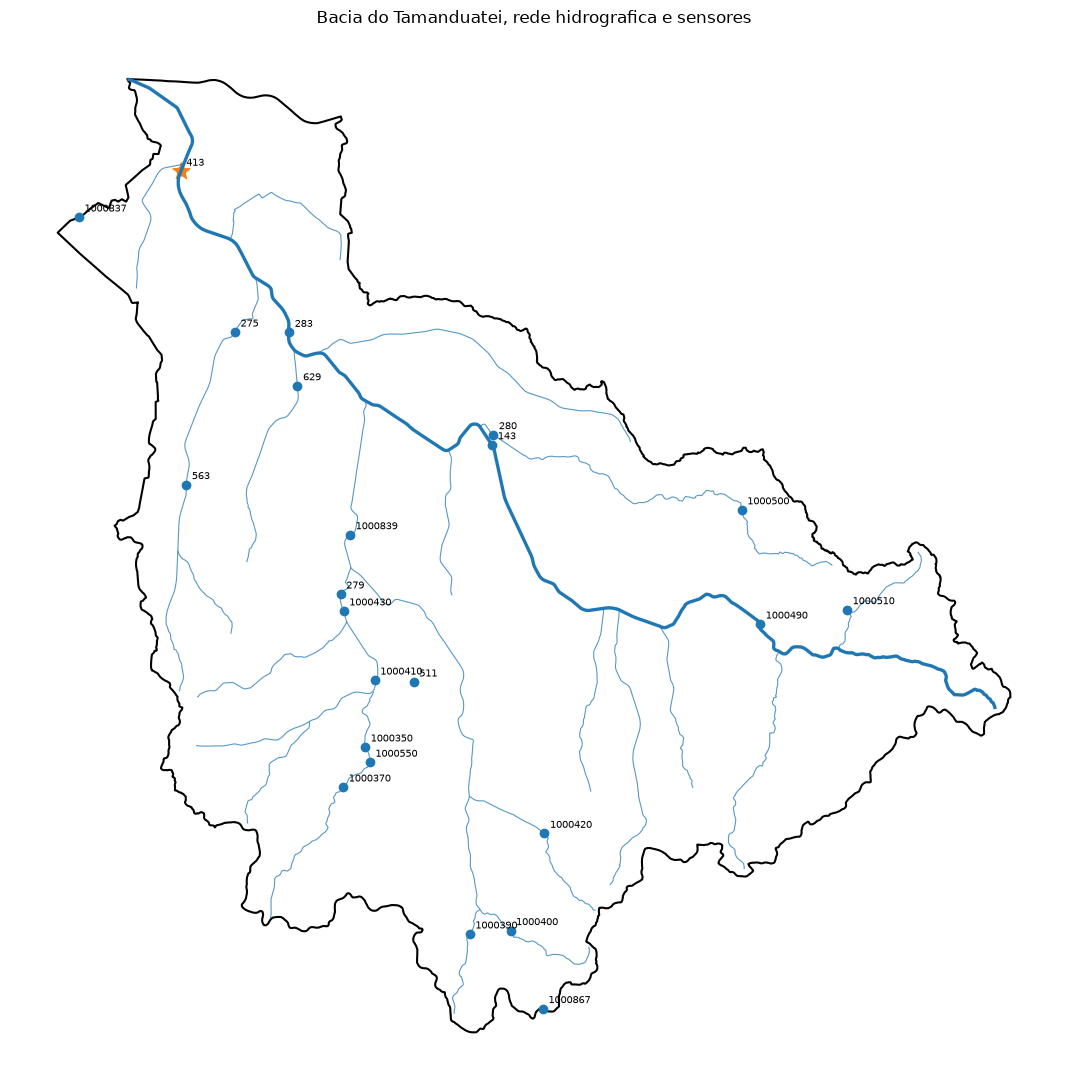

In [23]:
fig, ax = plt.subplots(figsize=(11, 11))
basin.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.5)
hydro.plot(ax=ax, linewidth=0.8, alpha=0.75)
river.plot(ax=ax, linewidth=2.4)
gauges.plot(ax=ax, markersize=36)
stage413.plot(ax=ax, markersize=160, marker="*")

for _, row in gauges.dropna(subset=["_station_id"]).iterrows():
    ax.annotate(
        str(int(row["_station_id"])),
        (row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7,
    )

ax.set_title("Bacia do Tamanduatei, rede hidrografica e sensores")
ax.set_axis_off()
plt.tight_layout()
save_figure(fig, "mapa_bacia_rede_sensores")
plt.show()

In [24]:
# Salva uma camada pronta para abrir no QGIS.
gpkg = OUTPUTS / "gauges_with_ids.gpkg"
gauges.to_file(gpkg, layer="rain_gauges", driver="GPKG")
print("GeoPackage salvo em:", gpkg.relative_to(ROOT))

GeoPackage salvo em: outputs\gauges_with_ids.gpkg


In [25]:
mainstem_info = pd.DataFrame({
    "station": [1000490, 143, 283, 413],
    "distance_upstream_to_413_km": [24.70, 13.55, 5.83, 0.0],
    "ordem_aproximada": [1, 2, 3, 4],
})
save_table(mainstem_info, "mainstem_order", preview_rows=10)

**Tabela completa salva em:**  
- `outputs\tables\mainstem_order.csv`  
- `outputs\tables\mainstem_order.html`  
Mostrando apenas as primeiras 4 linhas:

,station,distance_upstream_to_413_km,ordem_aproximada
0,1000490,24.70,1
1,143,13.55,2
2,283,5.83,3
3,413,0.00,4


,station,distance_upstream_to_413_km,ordem_aproximada
0,1000490,24.70,1
1,143,13.55,2
2,283,5.83,3
3,413,0.00,4


In [26]:
# Resumo legivel dos atributos da hidrografia.
hydro_attr = hydro.drop(columns="geometry").copy()
save_table(hydro_attr, "hydrography_attributes", preview_rows=20)

print("\nValores unicos das principais colunas textuais:")
for col in hydro_attr.columns:
    vals = hydro_attr[col].dropna().astype(str).unique()
    if 1 <= len(vals) <= 50:
        print(f"\n{col}:")
        print(vals)

**Tabela completa salva em:**  
- `outputs\tables\hydrography_attributes.csv`  
- `outputs\tables\hydrography_attributes.html`  
Mostrando apenas as primeiras 20 linhas:

,ID,LENGTH,DIR,DATA,MUN,DIST,TIPO,NOM_TIPO,NOM_PREP,NOME,...,EXT_KM,BACHID_5,BACHID_4,BACHID_3,BACHID_2,BACHID_1,UGRH_COD,UGRH_NOM,OBS,Deletar
0,209697,2.58,0,1097,SAO PAULO,SE,CURSO D AGUA,CORREGO,NaN,ITORORO,...,2.6,None,NaN,NaN,TAMANDUATEI,TIETE,6.3.5,RIO TAMANDUATEI INFERIOR,None,10
1,179904,1.70,0,721,SAO BERNARDO DO CAMPO,SAO BERNARDO DO CAMPO,CURSO D AGUA,RIBEIRAO,DOS,COUROS,...,1.7,None,COUROS,MENINOS,TAMANDUATEI,TIETE,6.2.2,RIO TAMANDUATEI MEDIO E CABECEIRAS,None,10
2,179972,4.88,0,722,SAO PAULO,SACOMA,CURSO D AGUA,RIBEIRAO,DOS,MENINOS,...,4.9,None,NaN,MENINOS,TAMANDUATEI,TIETE,6.2.2,RIO TAMANDUATEI MEDIO E CABECEIRAS,None,10
3,180293,3.72,0,1207,SAO CAETANO DO SUL,SAO CAETANO DO SUL,CURSO D AGUA,CORREGO,DO,MOINHO,...,3.7,None,NaN,NaN,TAMANDUATEI,TIETE,6.2.2,RIO TAMANDUATEI MEDIO E CABECEIRAS,None,10
4,180588,0.17,0,1206,SAO CAETANO DO SUL,SAO CAETANO DO SUL,CURSO D AGUA,CORREGO,DO,MOINHO,...,0.2,None,NaN,NaN,TAMANDUATEI,TIETE,6.2.2,RIO TAMANDUATEI MEDIO E CABECEIRAS,None,10
5,180603,0.15,0,1205,SAO CAETANO DO SUL,SAO CAETANO DO SUL,CURSO D AGUA,CORREGO,DO,MOINHO,...,0.1,None,NaN,NaN,TAMANDUATEI,TIETE,6.2.2,RIO TAMANDUATEI MEDIO E CABECEIRAS,None,10
6,180618,0.21,0,1204,SAO CAETANO DO SUL,SAO CAETANO DO SUL,CURSO D AGUA,CORREGO,DO,MOINHO,...,0.2,None,NaN,NaN,TAMANDUATEI,TIETE,6.2.2,RIO TAMANDUATEI MEDIO E CABECEIRAS,None,10
7,180695,10.04,0,726,SAO PAULO,SAO LUCAS,CURSO D AGUA,CORREGO,DA,MOOCA,...,10.0,None,NaN,NaN,TAMANDUATEI,TIETE,6.3.5,RIO TAMANDUATEI INFERIOR,None,10
8,185503,4.09,0,1202,SAO BERNARDO DO CAMPO,SAO BERNARDO DO CAMPO,CURSO D AGUA,CORREGO,NaN,SARACANTA,...,4.1,None,NaN,MENINOS,TAMANDUATEI,TIETE,6.2.2,RIO TAMANDUATEI MEDIO E CABECEIRAS,None,10
9,185810,6.46,0,908,SANTO ANDRE,SANTO ANDRE,CURSO D AGUA,RIBEIRAO,NaN,GUARARA,...,6.5,None,NaN,NaN,TAMANDUATEI,TIETE,6.2.2,RIO TAMANDUATEI MEDIO E CABECEIRAS,None,10



Valores unicos das principais colunas textuais:

ID:
<ArrowStringArray>
['209697', '179904', '179972', '180293', '180588', '180603', '180618',
 '180695', '185503', '185810', '186127', '186313', '186381', '186423',
 '186720', '187260', '187498', '187549', '187669', '190921', '175621',
 '175862', '175888', '176544', '176730', '176867', '177016', '177114',
 '177392', '177443', '177703', '177734', '177762', '177816', '177841',
 '177917', '178067', '178317', '178344', '178417', '178842', '178943',
 '179008', '179220', '179353', '179400', '210224', '210359', '210503']
Length: 49, dtype: str

LENGTH:
<ArrowStringArray>
[ '2.58',   '1.7',  '4.88',  '3.72',  '0.17',  '0.15',  '0.21', '10.04',
  '4.09',  '6.46',  '2.85',  '1.53',   '0.7',  '4.64',  '4.86',  '2.54',
  '0.99',  '1.18', '12.66',   '4.1',  '3.26',  '0.31',  '4.12',  '1.99',
  '1.93',  '3.34',  '1.74',   '5.2',   '2.1',  '1.03',   '0.5',  '0.65',
  '1.13',  '1.72',  '7.34',  '0.51',  '2.93',  '7.99',  '2.06',  '2.27',
  '6.81',  '2.

In [27]:
centroid_candidates = list(SHP.rglob("CentroidCells_1km_Tamanduatei_WGS84.shp"))
if not centroid_candidates:
    display(Markdown(
        "**Centroides do radar ainda nao extraidos.** "
        "Extraia `CentroidCells_1km_Tamanduatei_WGS84.rar` dentro de `Data/SHP/`."
    ))
else:
    centroids = gpd.read_file(centroid_candidates[0])
    print("Centroides encontrados:", len(centroids))
    centroids.drop(columns="geometry").to_csv(TABLES / "radar_centroid_attributes.csv", index=False)

    fig, ax = plt.subplots(figsize=(11, 11))
    basin.plot(ax=ax, facecolor="none", edgecolor="black")
    hydro.plot(ax=ax, linewidth=0.6, alpha=0.6)
    centroids.to_crs(basin.crs).plot(ax=ax, markersize=8, alpha=0.5)
    ax.set_title(f"Centroides de radar sobre a bacia (n={len(centroids)})")
    ax.set_axis_off()
    plt.tight_layout()
    save_figure(fig, "mapa_centroides_radar")
    plt.show()

**Centroides do radar ainda nao extraidos.** Extraia `CentroidCells_1km_Tamanduatei_WGS84.rar` dentro de `Data/SHP/`.